# TB District Retention Analysis — 2024

## Research question

**Which variables are most strongly associated with a district’s inability to retain drug-susceptible Tuberculosis (TB) patients in continuous care in 2024?**

### Analytical approach

This notebook follows the material covered in Weeks 1–3:

1. Data understanding and data quality
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Supervised learning
5. Explanatory linear regression

The analysis focuses on **district-level data**. The target variable is the **TB DS client lost to follow-up rate**, where a higher rate represents poorer retention in continuous care.

> **Important:** Association does not imply causation. The regression results identify statistical relationships in the 2024 district-level data; they do not prove that one variable causes TB patients to be lost to follow-up.


## 1. Import libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")


Libraries imported successfully.


## Student details
This is the group that had an unfortunate circumstances that left us with only two members in the group, and we were given a concession for both assignments 1 and 2.

In [33]:
student_names = ["Maleka Shellton", "Odwa Yamile"]  # FULL names of group members 
student_numbers = ["2539990", "2593714"]  # Student numbers of each group member 

assert len(student_names) == len(student_numbers), "All student names must have an associated student number and vice-versa"
assert np.all([type(x) == str for x in student_numbers]), "All student numbers must be represented as strings"
print("Student names and numbers validated successfully.")

Student names and numbers validated successfully.


## 2. Loading the Data collected from the District health barometer

The supplied Excel workbook contains district-level observations for 52 South African health districts and 11 variables. The outcome is the **TB DS client lost to follow-up rate**, while the remaining numerical indicators are candidate explanatory variables.


In [34]:
df = pd.read_excel(r"C:\Users\2539990\Downloads\TB_District_Retention_Analysis_2024.xlsx")
df.head()


,geo_prov,geo_area,TB DS client lost to follow up rate,TB DS death rate,TB/HIV co-infected client on ART rate (ETR.Net),% of target tested for TB,Professional nurses per 100 000 population,Provincial & LG District Health Services expenditure per capita (uninsured),Provincial & LG PHC expenditure per PHC headcount,Expenditure per patient day equivalent (district hospitals),Medical scheme coverage (ave)
0,EC,A Nzo DM: DC44,7.1,7.3,96.41,61.904,128.141,2200.440,567.171,3190.798,4.3
1,NaN,Amathole DM: DC12,7.1,5.3,95.12,89.030,142.463,2918.596,602.935,4173.719,5.8
2,NaN,Buffalo City MM: BUF,6.8,3.9,94.76,60.547,140.495,2610.908,740.645,4043.416,20.9
3,NaN,C Hani DM: DC13,11.0,6.1,95.18,72.839,131.653,3280.897,662.428,3760.107,5.4
4,NaN,Joe Gqabi DM: DC14,9.4,6.0,95.22,190.385,141.632,3527.770,642.088,3974.569,5.5


## 3. Inspect the dataset

In [35]:
display(df.head(10))


,geo_prov,geo_area,TB DS client lost to follow up rate,TB DS death rate,TB/HIV co-infected client on ART rate (ETR.Net),% of target tested for TB,Professional nurses per 100 000 population,Provincial & LG District Health Services expenditure per capita (uninsured),Provincial & LG PHC expenditure per PHC headcount,Expenditure per patient day equivalent (district hospitals),Medical scheme coverage (ave)
0,EC,A Nzo DM: DC44,7.1,7.3,96.41,61.904,128.141,2200.440,567.171,3190.798,4.3
1,NaN,Amathole DM: DC12,7.1,5.3,95.12,89.030,142.463,2918.596,602.935,4173.719,5.8
2,NaN,Buffalo City MM: BUF,6.8,3.9,94.76,60.547,140.495,2610.908,740.645,4043.416,20.9
3,NaN,C Hani DM: DC13,11.0,6.1,95.18,72.839,131.653,3280.897,662.428,3760.107,5.4
4,NaN,Joe Gqabi DM: DC14,9.4,6.0,95.22,190.385,141.632,3527.770,642.088,3974.569,5.5
5,NaN,N Mandela Bay MM: NMA,15.0,4.0,96.62,50.183,126.806,1850.304,661.269,3647.879,21.3
6,NaN,OR Tambo DM: DC15,6.1,4.3,97.01,72.947,110.755,2268.030,761.661,4862.046,4.7
7,NaN,Sarah Baartman DM: DC10,13.7,4.1,93.21,68.111,153.549,2866.155,507.622,3583.719,10.3
8,FS,Fezile Dabi DM: DC20,7.4,6.0,89.46,92.078,136.640,2021.899,609.083,1712.198,15.2
9,NaN,Lejweleputswa DM: DC18,10.6,7.8,94.38,45.953,193.090,1997.484,851.495,3193.155,14.0


In [36]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
for column in df.columns:
    print("-", column)


Dataset shape: (52, 11)

Column names:
- geo_prov
- geo_area
- TB DS client lost to follow up rate
- TB DS death rate
- TB/HIV co-infected client on ART rate (ETR.Net)
- % of target tested for TB
- Professional nurses per 100 000 population
- Provincial & LG District Health Services expenditure per capita (uninsured)
- Provincial & LG PHC expenditure per PHC headcount
- Expenditure per patient day equivalent (district hospitals)
- Medical scheme coverage (ave)


## 4. Standardise column names

converting columns to lowercase and spaces/special characters are replaced with underscores. This makes it easier to read and reduces errors when selecting variables.


In [37]:
original_columns = df.columns.tolist()

def clean_column_name(column):
    name = str(column).strip().lower()
    name = "".join(ch if ch.isalnum() else "_" for ch in name)
    name = "_".join(part for part in name.split("_") if part)
    return name

new_columns = []
used_names = set()

for column in df.columns:
    base = clean_column_name(column)
    name = base
    counter = 2
    while name in used_names:
        name = f"{base}_{counter}"
        counter += 1
    used_names.add(name)
    new_columns.append(name)

df.columns = new_columns

print("Cleaned column names:")
print(df.columns.tolist())


Cleaned column names:
['geo_prov', 'geo_area', 'tb_ds_client_lost_to_follow_up_rate', 'tb_ds_death_rate', 'tb_hiv_co_infected_client_on_art_rate_etr_net', 'of_target_tested_for_tb', 'professional_nurses_per_100_000_population', 'provincial_lg_district_health_services_expenditure_per_capita_uninsured', 'provincial_lg_phc_expenditure_per_phc_headcount', 'expenditure_per_patient_day_equivalent_district_hospitals', 'medical_scheme_coverage_ave']


## 5. Identify the target and candidate explanatory variables

The target is:

**TB DS client lost to follow-up rate**

The explanatory variables are health-system and TB-related indicators available in the dataset. Geographic identifiers such as province and district name are retained for identification but are not treated as numerical predictors.


In [38]:
target = 'tb_ds_client_lost_to_follow_up_rate'

candidate_features = ['tb_ds_death_rate', 'tb_hiv_co_infected_client_on_art_rate_etr_net', 'of_target_tested_for_tb', 'professional_nurses_per_100_000_population', 'provincial_lg_district_health_services_expenditure_per_capita_uninsured', 'provincial_lg_phc_expenditure_per_phc_headcount', 'expenditure_per_patient_day_equivalent_district_hospitals', 'medical_scheme_coverage_ave']

print("Target variable:")
print(target)

print("\nCandidate explanatory variables:")
for feature in candidate_features:
    print("-", feature)


Target variable:
tb_ds_client_lost_to_follow_up_rate

Candidate explanatory variables:
- tb_ds_death_rate
- tb_hiv_co_infected_client_on_art_rate_etr_net
- of_target_tested_for_tb
- professional_nurses_per_100_000_population
- provincial_lg_district_health_services_expenditure_per_capita_uninsured
- provincial_lg_phc_expenditure_per_phc_headcount
- expenditure_per_patient_day_equivalent_district_hospitals
- medical_scheme_coverage_ave


## 6. Describe the variables considered

The following table provides the analytical role of each selected variable. The exact definitions should be checked against the DHB indicator-definition sheet when writing the final report.


In [39]:
variable_description = pd.DataFrame({
    "Variable": [target] + candidate_features,
    "Role": (
        ["Target / dependent variable"] +
        ["Explanatory / independent variable"] * len(candidate_features)
    )
})

display(variable_description)


,Variable,Role
0,tb_ds_client_lost_to_follow_up_rate,Target / dependent variable
1,tb_ds_death_rate,Explanatory / independent variable
2,tb_hiv_co_infected_client_on_art_rate_etr_net,Explanatory / independent variable
3,of_target_tested_for_tb,Explanatory / independent variable
4,professional_nurses_per_100_000_population,Explanatory / independent variable
5,provincial_lg_district_health_services_expendi...,Explanatory / independent variable
6,provincial_lg_phc_expenditure_per_phc_headcount,Explanatory / independent variable
7,expenditure_per_patient_day_equivalent_distric...,Explanatory / independent variable
8,medical_scheme_coverage_ave,Explanatory / independent variable


## 7. Data quality checks

- Missing values
- Duplicate rows
- Data types
- Descriptive statistics
- Potentially unusual values

These checks are important because poor data quality can produce misleading statistical results.


In [40]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))


Data types:


,dtype
geo_prov,str
geo_area,str
tb_ds_client_lost_to_follow_up_rate,float64
tb_ds_death_rate,float64
tb_hiv_co_infected_client_on_art_rate_etr_net,float64
of_target_tested_for_tb,float64
professional_nurses_per_100_000_population,float64
provincial_lg_district_health_services_expenditure_per_capita_uninsured,float64
provincial_lg_phc_expenditure_per_phc_headcount,float64
expenditure_per_patient_day_equivalent_district_hospitals,float64


In [41]:
print("Missing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_count"))


Missing values:


,missing_count
geo_prov,43
geo_area,0
tb_ds_client_lost_to_follow_up_rate,0
tb_ds_death_rate,0
tb_hiv_co_infected_client_on_art_rate_etr_net,0
of_target_tested_for_tb,0
professional_nurses_per_100_000_population,0
provincial_lg_district_health_services_expenditure_per_capita_uninsured,0
provincial_lg_phc_expenditure_per_phc_headcount,0
expenditure_per_patient_day_equivalent_district_hospitals,0


In [42]:
# Checking for duplicated area labels
df["geo_area"].duplicated().sum()
df[df["geo_area"].duplicated(keep=False)]


,geo_prov,geo_area,tb_ds_client_lost_to_follow_up_rate,tb_ds_death_rate,tb_hiv_co_infected_client_on_art_rate_etr_net,of_target_tested_for_tb,professional_nurses_per_100_000_population,provincial_lg_district_health_services_expenditure_per_capita_uninsured,provincial_lg_phc_expenditure_per_phc_headcount,expenditure_per_patient_day_equivalent_district_hospitals,medical_scheme_coverage_ave


In [43]:
# Filling in missing province labels using forward-fill method
df["geo_prov"] = df["geo_prov"].ffill()
print("Missing province labels after forward-fill:", df["geo_prov"].isna().sum())

Missing province labels after forward-fill: 0


In [44]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [45]:
print("Descriptive statistics:")
df.describe().T


Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
tb_ds_client_lost_to_follow_up_rate,52.0,6.865000,4.395398,0.270,3.45000,6.1000,9.57500,18.000
tb_ds_death_rate,52.0,5.586538,1.804138,2.400,4.00000,5.6000,6.90000,9.500
tb_hiv_co_infected_client_on_art_rate_etr_net,52.0,91.701731,5.733756,69.140,89.37250,93.4850,95.60250,98.030
of_target_tested_for_tb,52.0,118.579846,79.283739,45.953,65.79650,90.2755,138.60300,390.243
professional_nurses_per_100_000_population,52.0,603.374038,829.939415,52.256,123.89450,183.4680,984.25000,3834.000
provincial_lg_district_health_services_expenditure_per_capita_uninsured,52.0,2691.725385,692.689729,1615.374,2214.73500,2675.0090,3135.10200,5167.482
provincial_lg_phc_expenditure_per_phc_headcount,52.0,741.889904,143.624801,480.281,649.21525,721.0510,835.84750,1248.208
expenditure_per_patient_day_equivalent_district_hospitals,52.0,3953.305096,1111.995180,1712.198,3252.38925,3730.6050,4364.79425,7552.628
medical_scheme_coverage_ave,52.0,12.785192,6.449618,4.300,7.15750,11.2700,18.51750,30.000


## 8. Check numerical ranges

Rates and percentages should have plausible values. We inspect minimum and maximum values before modelling rather than automatically deleting unusual observations.


In [46]:
numeric_columns = df.select_dtypes(include=np.number).columns

range_check = pd.DataFrame({
    "minimum": df[numeric_columns].min(),
    "maximum": df[numeric_columns].max(),
    "mean": df[numeric_columns].mean(),
    "median": df[numeric_columns].median()
})

display(range_check)


,minimum,maximum,mean,median
tb_ds_client_lost_to_follow_up_rate,0.270,18.000,6.865000,6.1000
tb_ds_death_rate,2.400,9.500,5.586538,5.6000
tb_hiv_co_infected_client_on_art_rate_etr_net,69.140,98.030,91.701731,93.4850
of_target_tested_for_tb,45.953,390.243,118.579846,90.2755
professional_nurses_per_100_000_population,52.256,3834.000,603.374038,183.4680
provincial_lg_district_health_services_expenditure_per_capita_uninsured,1615.374,5167.482,2691.725385,2675.0090
provincial_lg_phc_expenditure_per_phc_headcount,480.281,1248.208,741.889904,721.0510
expenditure_per_patient_day_equivalent_district_hospitals,1712.198,7552.628,3953.305096,3730.6050
medical_scheme_coverage_ave,4.300,30.000,12.785192,11.2700


## 9. Select the analysis dataset

Only the target and candidate explanatory variables are used in the first analysis. Rows with missing values in these variables are removed for the regression analysis.

This is a complete-case approach. The number of observations removed is reported so that the decision is transparent.


In [47]:
analysis_columns = [target] + candidate_features
analysis_df = df[analysis_columns].copy()

before = len(analysis_df)
analysis_df = analysis_df.dropna()
after = len(analysis_df)

print("Observations before removing missing values:", before)
print("Observations after removing missing values:", after)
print("Observations removed:", before - after)

display(analysis_df.head(10))


Observations before removing missing values: 52
Observations after removing missing values: 52
Observations removed: 0


,tb_ds_client_lost_to_follow_up_rate,tb_ds_death_rate,tb_hiv_co_infected_client_on_art_rate_etr_net,of_target_tested_for_tb,professional_nurses_per_100_000_population,provincial_lg_district_health_services_expenditure_per_capita_uninsured,provincial_lg_phc_expenditure_per_phc_headcount,expenditure_per_patient_day_equivalent_district_hospitals,medical_scheme_coverage_ave
0,7.1,7.3,96.41,61.904,128.141,2200.440,567.171,3190.798,4.3
1,7.1,5.3,95.12,89.030,142.463,2918.596,602.935,4173.719,5.8
2,6.8,3.9,94.76,60.547,140.495,2610.908,740.645,4043.416,20.9
3,11.0,6.1,95.18,72.839,131.653,3280.897,662.428,3760.107,5.4
4,9.4,6.0,95.22,190.385,141.632,3527.770,642.088,3974.569,5.5
5,15.0,4.0,96.62,50.183,126.806,1850.304,661.269,3647.879,21.3
6,6.1,4.3,97.01,72.947,110.755,2268.030,761.661,4862.046,4.7
7,13.7,4.1,93.21,68.111,153.549,2866.155,507.622,3583.719,10.3
8,7.4,6.0,89.46,92.078,136.640,2021.899,609.083,1712.198,15.2
9,10.6,7.8,94.38,45.953,193.090,1997.484,851.495,3193.155,14.0


# 10. Exploratory Data Analysis (EDA)

EDA is used to understand the distributions of the variables and explore relationships before fitting the regression model.


## 10.1 Distribution of the target variable

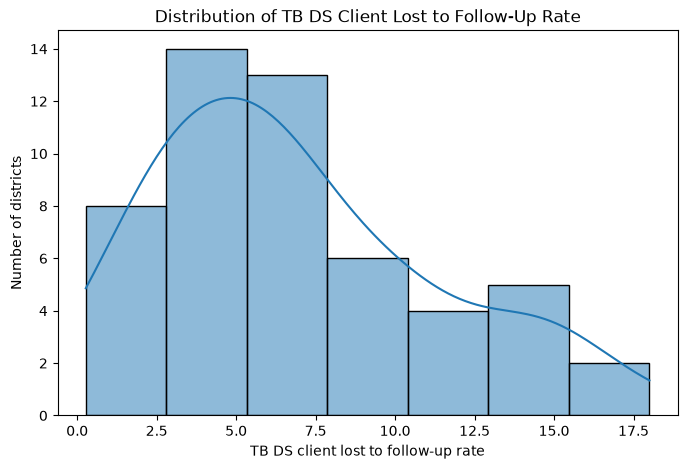

In [48]:
plt.figure(figsize=(8, 5))
sns.histplot(data=analysis_df, x=target, kde=True)
plt.title("Distribution of TB DS Client Lost to Follow-Up Rate")
plt.xlabel("TB DS client lost to follow-up rate")
plt.ylabel("Number of districts")
plt.show()


## 10.2 Boxplot of the target

The boxplot helps identify possible outliers. An observation should not automatically be removed just because it is an outlier; it needs to be investigated and justified.


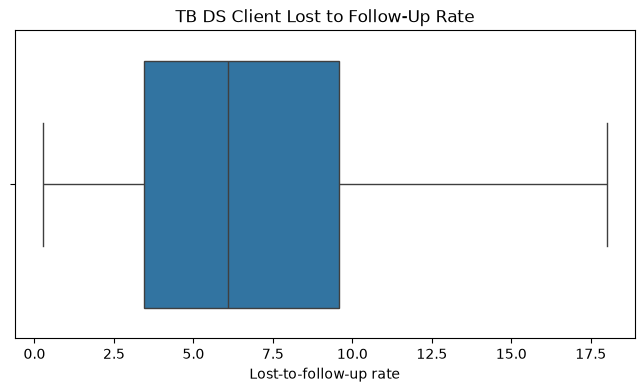

In [49]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=analysis_df[target])
plt.title("TB DS Client Lost to Follow-Up Rate")
plt.xlabel("Lost-to-follow-up rate")
plt.show()


## 10.3 Correlation matrix

Correlation provides an initial measure of the direction and strength of linear association between numerical variables.

- Values close to **+1** indicate a strong positive linear relationship.
- Values close to **-1** indicate a strong negative linear relationship.
- Values close to **0** indicate a weak linear relationship.



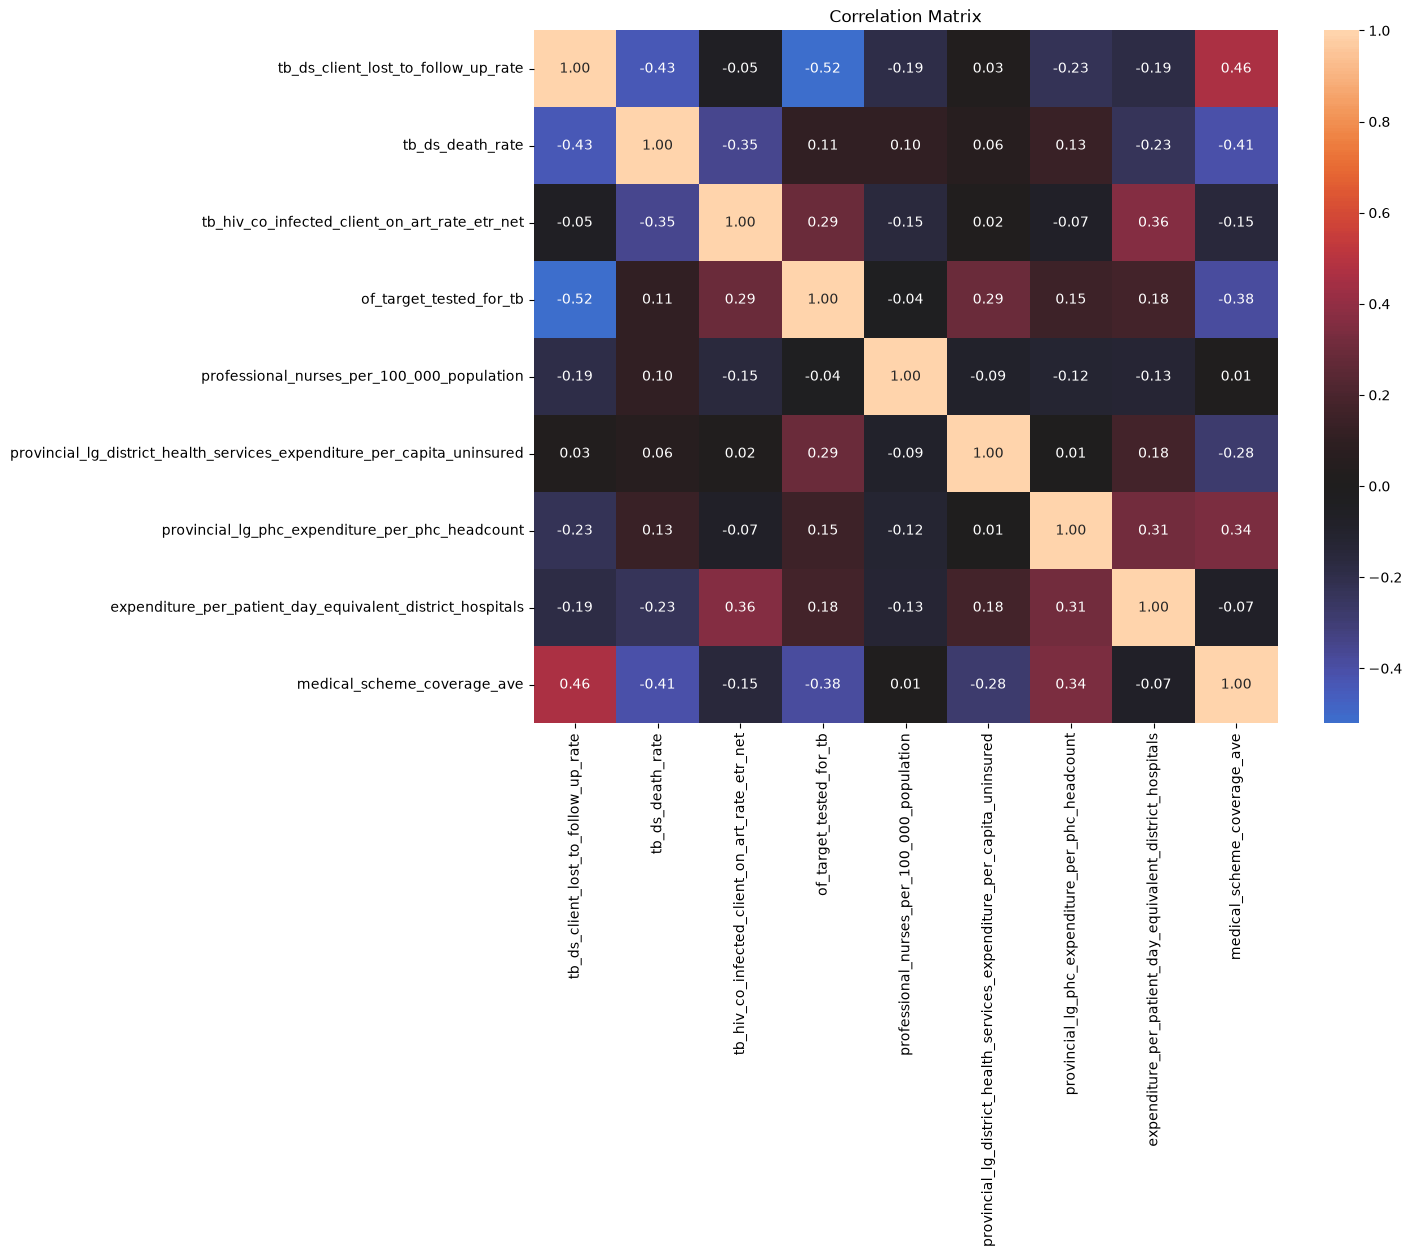

In [50]:
correlation_matrix = analysis_df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()


## 10.4 Correlation with the target

This table ranks the candidate variables by the absolute size of their correlation with TB lost-to-follow-up rate. It gives an initial indication of which variables have the strongest individual linear associations with the outcome.


In [51]:
target_correlations = (
    analysis_df.corr(numeric_only=True)[target]
    .drop(target)
    .to_frame("correlation")
)

target_correlations["absolute_correlation"] = target_correlations["correlation"].abs()
target_correlations = target_correlations.sort_values(
    "absolute_correlation", ascending=False
)

display(target_correlations)


,correlation,absolute_correlation
of_target_tested_for_tb,-0.521015,0.521015
medical_scheme_coverage_ave,0.463119,0.463119
tb_ds_death_rate,-0.434111,0.434111
provincial_lg_phc_expenditure_per_phc_headcount,-0.228035,0.228035
professional_nurses_per_100_000_population,-0.188521,0.188521
expenditure_per_patient_day_equivalent_district_hospitals,-0.187248,0.187248
tb_hiv_co_infected_client_on_art_rate_etr_net,-0.046102,0.046102
provincial_lg_district_health_services_expenditure_per_capita_uninsured,0.027836,0.027836


## 10.5 Scatterplots

Scatterplots allow us to inspect whether the relationships suggested by the correlations look approximately linear and whether unusual districts may be influencing the relationship.


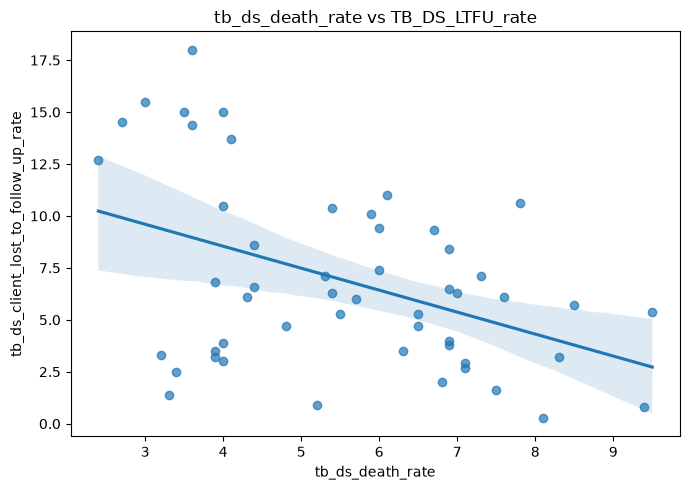

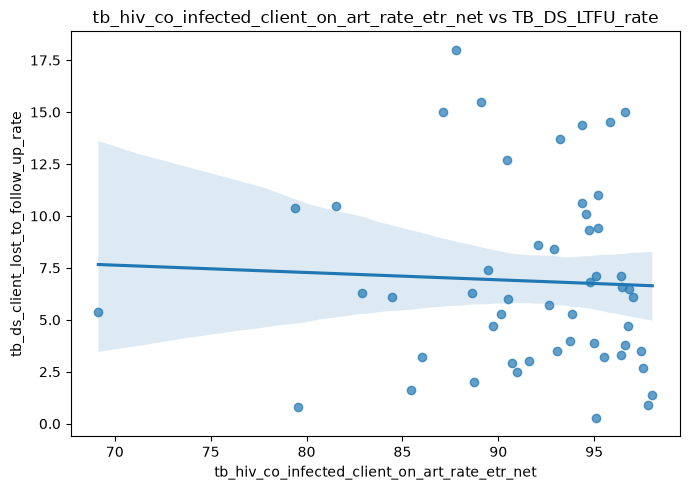

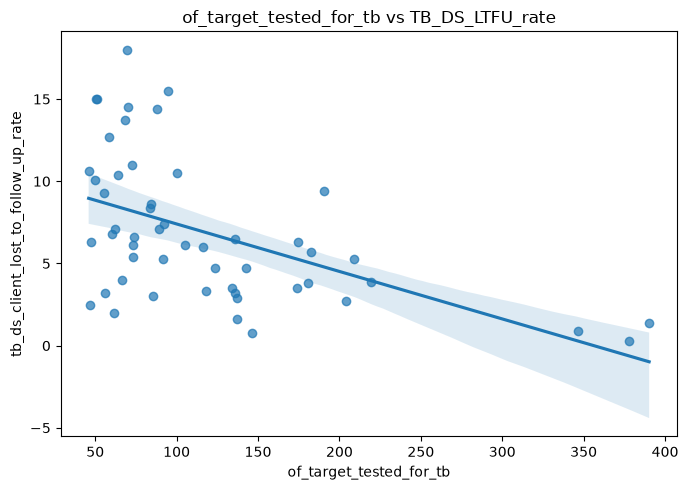

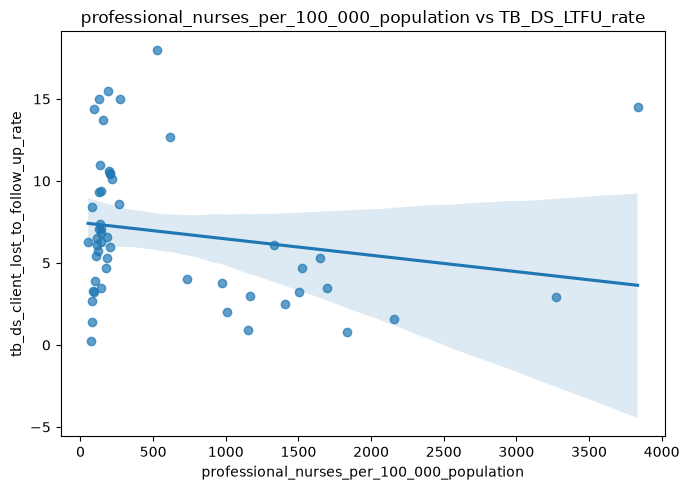

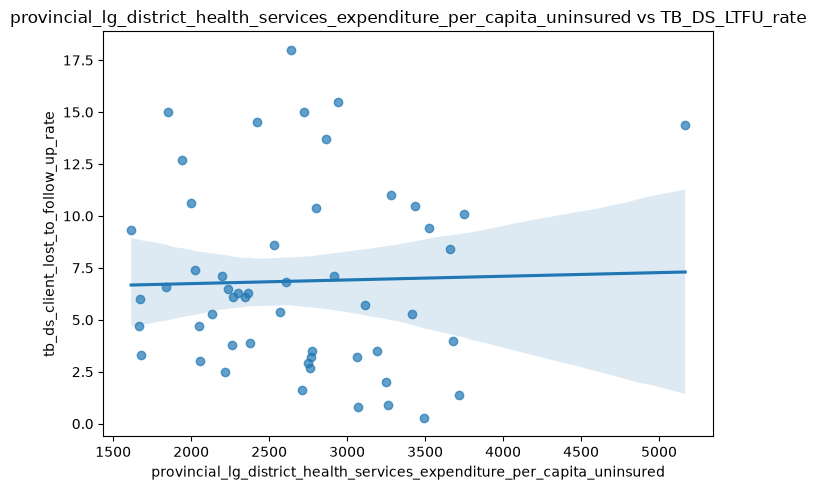

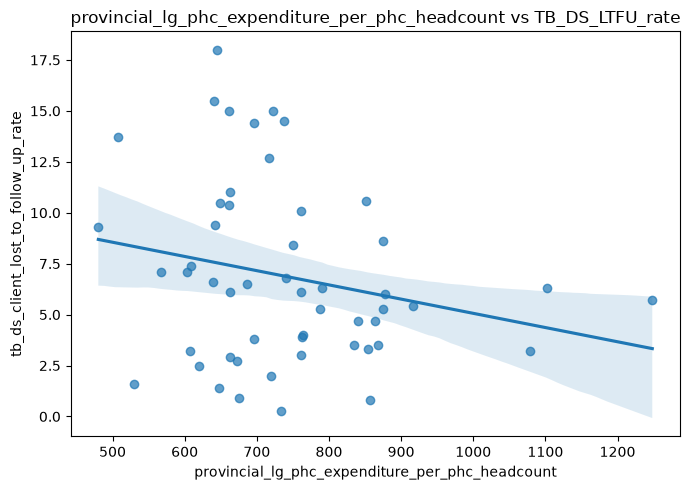

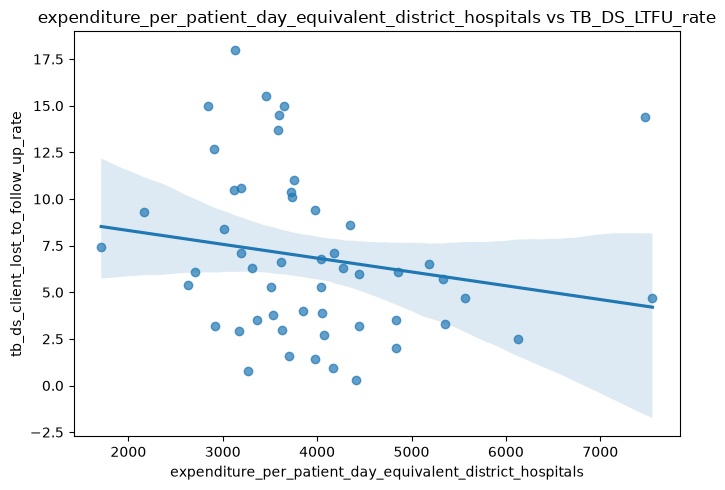

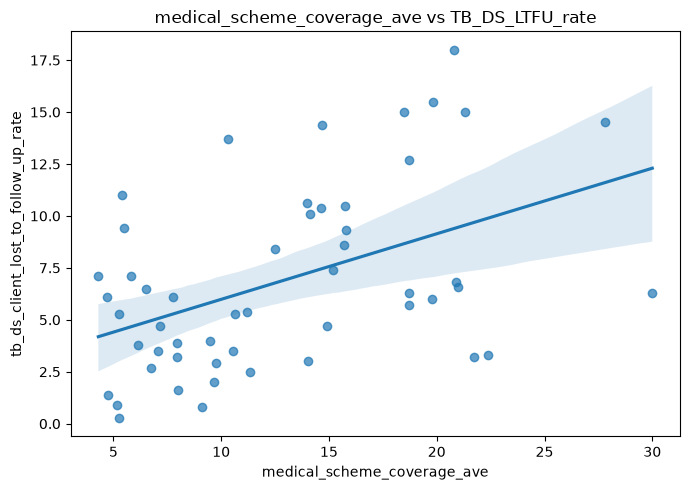

In [52]:
for feature in candidate_features:
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=analysis_df,
        x=feature,
        y=target,
        scatter_kws={"alpha": 0.7},
        line_kws={}
    )
    plt.title(f"{feature} vs TB_DS_LTFU_rate") # TB DS client lost to follow up rate (TB DS LTFU rate)
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()


# 11. Prepare data for Linear Regression

The research question is explanatory: we want to understand which available variables are most strongly associated with TB lost-to-follow-up rate.

A multiple linear regression model is therefore appropriate as an introductory supervised-learning method.

The model estimates:

**TB lost-to-follow-up rate = intercept + coefficients × explanatory variables + error**

The coefficient for each variable represents its estimated association with the target while holding the other included variables constant.


In [53]:
X = analysis_df[candidate_features]
y = analysis_df[target]

print("Features (X):", X.shape)
print("Target (y):", y.shape)


Features (X): (52, 8)
Target (y): (52,)


## 12. Train-test split




In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 41
Testing observations: 11


# 13. Fit the Linear Regression model

In [55]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear regression model fitted successfully.")


Linear regression model fitted successfully.


## 13.1 Model coefficients

The coefficients show the direction and estimated magnitude of association.

Because the predictors are measured on different scales, raw coefficients should not be used alone to decide which variable is strongest. We therefore also calculate standardised coefficients below.


In [56]:
coefficients = pd.DataFrame({
    "feature": candidate_features,
    "coefficient": linear_model.coef_
}).sort_values("coefficient", key=lambda x: x.abs(), ascending=False)

display(coefficients)


,feature,coefficient
0,tb_ds_death_rate,-0.515358
7,medical_scheme_coverage_ave,0.322205
1,tb_hiv_co_infected_client_on_art_rate_etr_net,0.073771
2,of_target_tested_for_tb,-0.019581
5,provincial_lg_phc_expenditure_per_phc_headcount,-0.006429
4,provincial_lg_district_health_services_expendi...,0.001305
3,professional_nurses_per_100_000_population,-0.001021
6,expenditure_per_patient_day_equivalent_distric...,-0.000531


## 13.2 Standardised coefficients

Standardising the predictors puts them on a common scale. The absolute value of a standardised coefficient can then be used as a more meaningful comparison of relative association strength within the fitted model.


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_train, X_scaled_test, y_scaled_train, y_scaled_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

standardised_model = LinearRegression()
standardised_model.fit(X_scaled_train, y_scaled_train)

standardised_coefficients = pd.DataFrame({
    "feature": candidate_features,
    "standardised_coefficient": standardised_model.coef_
})

standardised_coefficients["absolute_standardised_coefficient"] = (
    standardised_coefficients["standardised_coefficient"].abs()
)

standardised_coefficients = standardised_coefficients.sort_values(
    "absolute_standardised_coefficient",
    ascending=False
)

display(standardised_coefficients)


,feature,standardised_coefficient,absolute_standardised_coefficient
7,medical_scheme_coverage_ave,2.058018,2.058018
2,of_target_tested_for_tb,-1.537428,1.537428
0,tb_ds_death_rate,-0.920793,0.920793
5,provincial_lg_phc_expenditure_per_phc_headcount,-0.914502,0.914502
4,provincial_lg_district_health_services_expendi...,0.895215,0.895215
3,professional_nurses_per_100_000_population,-0.839102,0.839102
6,expenditure_per_patient_day_equivalent_distric...,-0.585168,0.585168
1,tb_hiv_co_infected_client_on_art_rate_etr_net,0.418897,0.418897


# 14. Evaluate the regression model
- R² -- Proportion of variation in the target explained by the model.
- MAE -- Average absolute prediction error.
- RMSE -- Square-root of the average squared prediction error.



In [58]:
y_pred = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

model_metrics = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

display(model_metrics)


,Metric,Value
0,R²,0.348810
1,MAE,3.364838
2,RMSE,3.854790


## 14.1 Actual vs predicted values

In [59]:
# Creating a DataFrame to compare actual and predicted values
predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(predictions.sort_index())


,Actual,Predicted
0,6.6,11.826217
1,9.3,10.769659
2,12.7,11.554683
3,8.4,9.448002
4,3.0,7.693293
5,15.0,12.532469
6,3.2,9.478889
7,15.5,12.747040
8,11.0,7.572180
9,1.6,3.784605


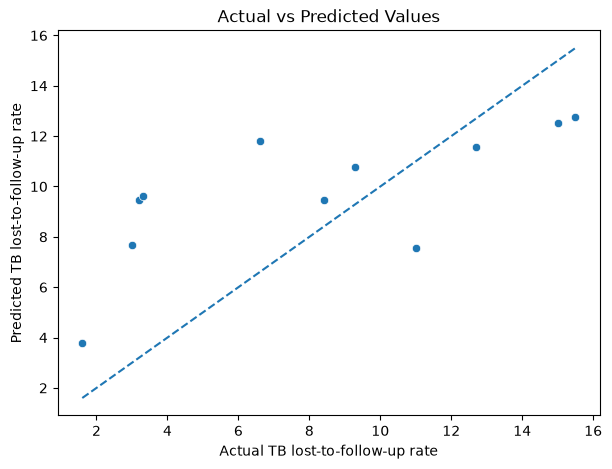

In [60]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual TB lost-to-follow-up rate")
plt.ylabel("Predicted TB lost-to-follow-up rate")
plt.title("Actual vs Predicted Values")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.show()


# 15. Identifying the strongest associations
- Positive coefficient -- Higher predictor values are associated with higher lost-to-follow-up rates, holding other predictors constant.
- Negative coefficient -- Higher predictor values are associated with lower lost-to-follow-up rates, holding other predictors constant.
- Larger absolute coefficient -- Stronger relative association in this model.


In [61]:
final_ranking = standardised_coefficients[
    ["feature", "standardised_coefficient", "absolute_standardised_coefficient"]
].copy()

display(final_ranking)


,feature,standardised_coefficient,absolute_standardised_coefficient
7,medical_scheme_coverage_ave,2.058018,2.058018
2,of_target_tested_for_tb,-1.537428,1.537428
0,tb_ds_death_rate,-0.920793,0.920793
5,provincial_lg_phc_expenditure_per_phc_headcount,-0.914502,0.914502
4,provincial_lg_district_health_services_expendi...,0.895215,0.895215
3,professional_nurses_per_100_000_population,-0.839102,0.839102
6,expenditure_per_patient_day_equivalent_distric...,-0.585168,0.585168
1,tb_hiv_co_infected_client_on_art_rate_etr_net,0.418897,0.418897


# 16. Model residuals

Residuals are the differences between the observed and predicted target values. Checking residuals helps assess whether a linear model is a reasonable approximation of the relationships in the data.


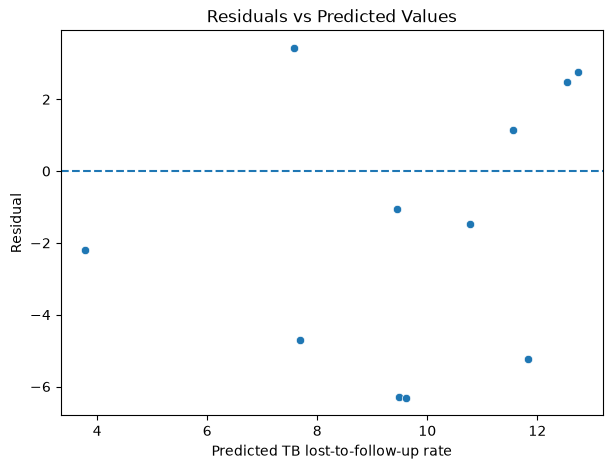

In [62]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted TB lost-to-follow-up rate")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()


## References
- World Health Organization. *Data Quality Assurance (DQA), Module 2: Desk Review*. WHO.https://www.who.int/data/data-collection-tools/health-service-data/data-quality-assurance-dqa/module-2-desk-review
- Health Systems Trust. District Health Barometer 2024/25. Available at: https://www.hst.org.za/publications/Pages/HSTDistrictHealthBarometer.aspx .
